In [1]:
import video
import visualizations
import scan_buffer

In [2]:
dataset_path = 'C:/Users/clack/Downloads/AnySense/lemon-pickup'
reference_path = '../lemon_pickup_reference.pt'

encoder = scan_buffer.ResNetHiddenEncoder()
scan_buffer.SimilarityEvaluator.create_reference(encoder, dataset_path, True, reference_path)

Encoding frames in batches of 32: 100%|██████████| 159/159 [00:09<00:00, 16.20it/s]


In [3]:
buffer = scan_buffer.ScanBuffer(encoder, scan_buffer.SimilarityEvaluator(reference_path, depth_weight=0.8))

video_scan_path = '../scans/scan-over-lemon-lab.mp4'
depth_scan_path = '../scans/scan-over-lemon-lab-depth'

rgb_scan_frames = video.load_video_frames(video_scan_path)
depth_scan_frames = video.depth_to_rgb(video.load_depth_frames_from_individual_binaries(depth_scan_path), resize=(256, 256))

angles = []
for i, (rgb, depth) in enumerate(zip(rgb_scan_frames, depth_scan_frames)):
    angle = i / len(rgb_scan_frames) * 360
    buffer.add_frame(rgb, 1 - 0.5 * depth, angle)
    angles.append(angle)

buffer.process()

Loading frames from ../scans/scan-over-lemon-lab.mp4: 100%|██████████| 221/221 [00:00<00:00, 263.19it/s]
Loading depth frames from ..\scans\scan-over-lemon-lab-depth: 100%|██████████| 221/221 [00:00<00:00, 1350.40it/s]


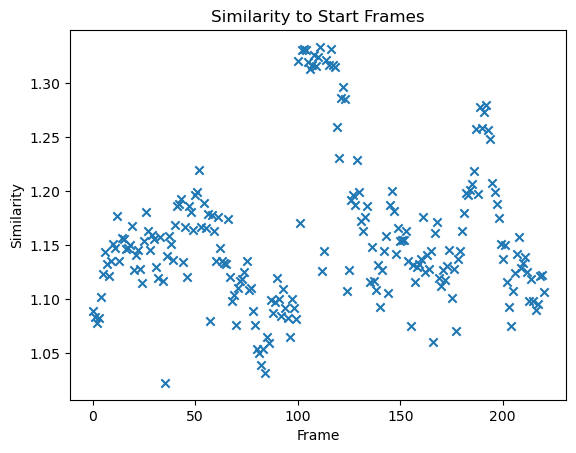

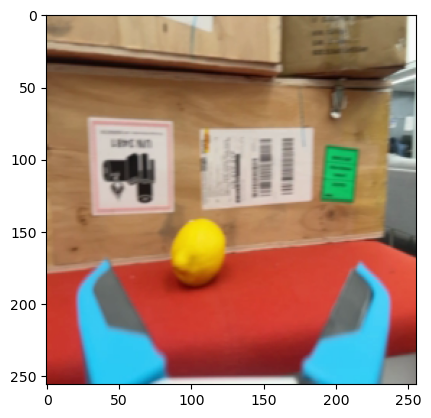

<Figure size 640x480 with 0 Axes>

In [4]:
selected_angle = buffer.retrieve_best_scan_angle(angle_tolerance=10, top_proportion=0.2)

visualizations.display_alignment_scores(buffer.scores)
visualizations.display_frame(rgb_scan_frames[angles.index(selected_angle)])